# Retail Demand Forecasting with Hierarchical Time Series

This notebook builds a structured retail demand forecasting workflow across multiple business levels: total sales, store-level sales, item-level sales, and store-item-level sales.

The goal is not only to forecast sales, but also to check whether forecasts are consistent across hierarchy levels. This is important because retail decisions are made at different levels: executives look at total demand, store managers focus on store demand, and inventory teams need store-item-level forecasts.

## 1. Environment Setup and Imports

In this step, we import the required Python libraries and connect the notebook with the reusable functions stored in the `src/` folder.

The notebook is used for storytelling, visualization, and business interpretation, while the reusable data processing, modeling, evaluation, and plotting logic is kept in separate Python modules.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) in sys.path:
    sys.path.remove(str(SRC_PATH))

sys.path.insert(0, str(SRC_PATH))

for module_name in [
    "data_prep",
    "hierarchy",
    "models",
    "evaluation",
    "visualization",
    "reconciliation"
]:
    if module_name in sys.modules:
        del sys.modules[module_name]

from data_prep import load_raw_data, basic_data_audit
from hierarchy import (
    create_hierarchical_dataframe,
    create_hierarchy_dict,
    create_darts_series,
    get_hierarchy_groups
)
from models import train_naive_seasonal, train_linear_regression
from evaluation import evaluate_all_levels, calculate_coherence_gap
from visualization import (
    plot_total_sales,
    plot_forecast_coherence,
    plot_metric_comparison,
    plot_coherence_gap_summary
)
from reconciliation import apply_bottom_up, apply_top_down, apply_mint

## 2. Load Raw Sales Data

We load the raw transaction-level sales data from the `data/raw/` folder.

Each row represents daily sales for a specific store and item combination. This format is suitable for building a store-item-level time series, which can later be aggregated into store, item, and total sales levels.

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "train.csv"

df = load_raw_data(DATA_PATH)
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## 3. Basic Data Audit

Before modeling, we check the size, date range, number of stores, number of items, missing values, and duplicate rows.

This step helps confirm whether the dataset has the expected retail structure and whether additional cleaning is needed before constructing time series.

In [3]:
audit = basic_data_audit(df)
audit

{'rows': 913000,
 'columns': 4,
 'date_min': Timestamp('2013-01-01 00:00:00'),
 'date_max': Timestamp('2017-12-31 00:00:00'),
 'unique_stores': 10,
 'unique_items': 50,
 'missing_values': {'date': 0, 'store': 0, 'item': 0, 'sales': 0},
 'duplicate_rows': np.int64(0)}

## 4. Total Sales Trend

We first visualize total daily sales to understand the overall demand pattern.

This gives a high-level business view of the data before moving into more granular store-item forecasting.

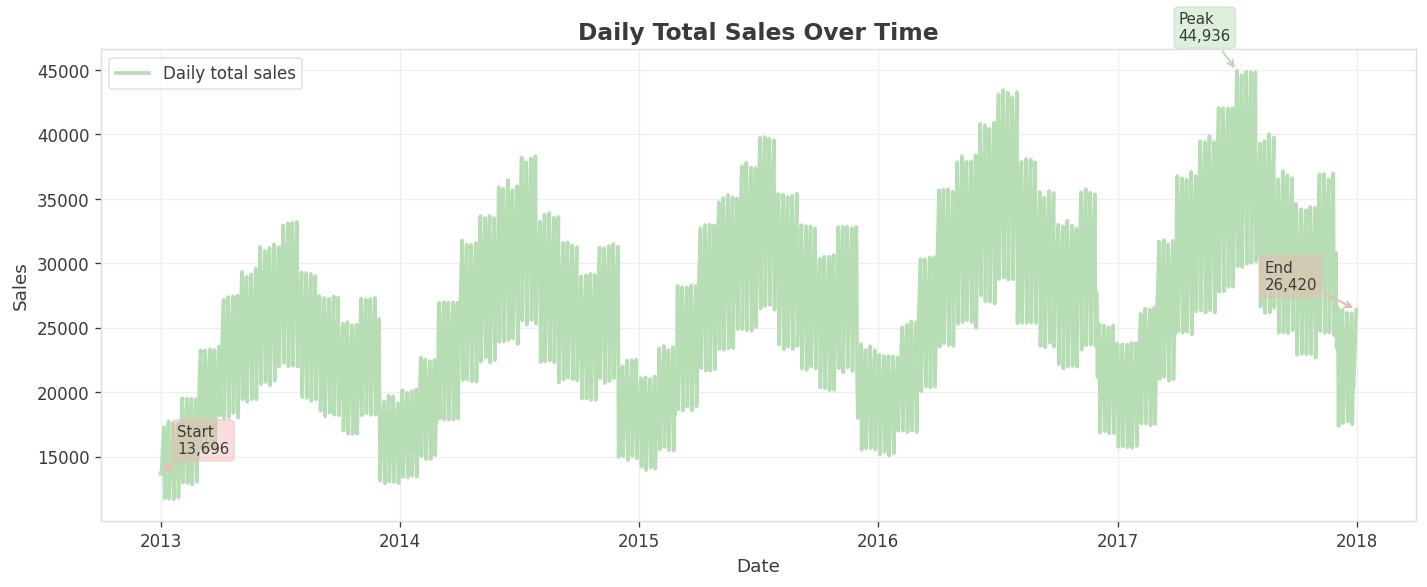

In [4]:
plot_total_sales(
    df,
    save_path=PROJECT_ROOT / "outputs" / "figures" / "daily_total_sales.png"
)


The total daily sales show a clear upward long-term trend from 2013 to 2017, with repeated seasonal fluctuations within each year.

The series starts at **13,696** sales units, reaches a peak of **44,936**, and ends at **26,420**. This indicates that the dataset is not stationary: demand grows over time and also follows recurring seasonal patterns.

From a business perspective, this means a simple average-based forecast would not be sufficient. A useful demand forecasting model needs to capture both trend and seasonality.

## 5. Build the Hierarchical Time Series

Retail demand exists at multiple levels:

- **Total level**: total sales across all stores and items
- **Store level**: sales aggregated by store
- **Item level**: sales aggregated by item
- **Store-item level**: sales for each specific store and item pair

In this step, we transform the raw data into a hierarchical time series structure. This allows us to model all related time series together and later check whether forecasts are coherent across levels.

In [5]:
hierarchy_df = create_hierarchical_dataframe(df)
hierarchy = create_hierarchy_dict(df)
groups = get_hierarchy_groups(df)

series = create_darts_series(hierarchy_df, hierarchy)

print("Hierarchy dataframe shape:", hierarchy_df.shape)
print("Number of hierarchy components:", len(hierarchy_df.columns))

Hierarchy dataframe shape: (1826, 561)
Number of hierarchy components: 561


The transformed dataset contains **1,826 daily observations** and **561 hierarchy components**.

These components represent four business decision levels:

- **1 total-level series**
- **10 store-level series**
- **50 item-level series**
- **500 store-item-level series**

This structure allows the project to evaluate demand forecasting not only at the aggregate business level, but also at the operational replenishment level.

## 6. Train-Test Split

We use the final 30 days as the test period and all previous observations as the training period.

This setup simulates a realistic forecasting problem: using historical sales data to predict future demand.

In [6]:
train, test = series[:-30], series[-30:]

print("Train period:", train.start_time(), "to", train.end_time())
print("Test period:", test.start_time(), "to", test.end_time())

Train period: 2013-01-01 00:00:00 to 2017-12-01 00:00:00
Test period: 2017-12-02 00:00:00 to 2017-12-31 00:00:00


## 7. Baseline Model: Linear Regression

We first train a simple global Linear Regression forecasting model using lagged historical sales values.

This baseline is useful because it is interpretable, fast to train, and provides a benchmark before trying more complex models.

In [7]:
lr_model = train_linear_regression(train, lags=30)
lr_pred = lr_model.predict(len(test))

lr_result = evaluate_all_levels(
    actual=test,
    predicted=lr_pred,
    hierarchy_groups=groups,
    model_name="Linear Regression"
)

lr_result

,model,level,MAPE,sMAPE,MAE,RMSE
0,Linear Regression,Total,6.7956,7.0316,1514.0357,1951.4305
1,Linear Regression,Store,7.1215,7.3558,159.5645,203.9148
2,Linear Regression,Item,8.5970,8.8581,37.7678,48.0195
3,Linear Regression,Store-Item,20.0480,19.9112,7.7838,9.6642


The Linear Regression model performs well at higher aggregation levels:

- **Total MAPE:** 6.80%
- **Store MAPE:** 7.12%
- **Item MAPE:** 8.60%
- **Store-item MAPE:** 20.05%

The result shows a clear hierarchy effect: forecasting becomes harder as the level becomes more granular. Total, store, and item-level demand are relatively stable because aggregation reduces noise. In contrast, store-item demand is more volatile and more sensitive to local demand changes, which explains the higher error at the most detailed level.

This is an important business insight because store-item forecasts are the most relevant for replenishment decisions, but they are also the most difficult to predict accurately.

## 8. Forecast Coherence Before Reconciliation

After evaluating accuracy, we check whether the forecast is internally coherent across hierarchy levels.

In hierarchical retail forecasting, coherence means:

- the sum of store-level forecasts equals the total forecast;
- the sum of item-level forecasts equals the total forecast;
- the sum of store-item-level forecasts equals the total forecast.

This check is important because coherent forecasts are easier to use in business planning. If different hierarchy levels produce conflicting numbers, finance, operations, and replenishment teams may work from inconsistent demand signals.

In this case, the Linear Regression forecast is already almost perfectly coherent. The observed gaps are around `1e-11`, which is effectively zero and can be treated as numerical floating-point noise rather than a meaningful business inconsistency.

In [8]:
lr_gap_before = calculate_coherence_gap(
    predicted=lr_pred,
    stores=groups["stores"],
    items=groups["items"],
    store_items=groups["store_items"]
)

lr_gap_before.head()

,Total,Sum_Store,Sum_Item,Sum_Store_Item,Store_Gap,Item_Gap,Store_Item_Gap,Abs_Store_Gap,Abs_Item_Gap,Abs_Store_Item_Gap
date,,,,,,,,,,
2017-12-02,26527.920994,26527.920994,26527.920994,26527.920994,-3.274181e-11,-3.274181e-11,-1.818989e-11,3.274181e-11,3.274181e-11,1.818989e-11
2017-12-03,28388.275670,28388.275670,28388.275670,28388.275670,1.455192e-11,2.546585e-11,6.548362e-11,1.455192e-11,2.546585e-11,6.548362e-11
2017-12-04,16529.997682,16529.997682,16529.997682,16529.997682,-3.637979e-12,0.000000e+00,1.455192e-11,3.637979e-12,0.000000e+00,1.455192e-11
2017-12-05,21555.725041,21555.725041,21555.725041,21555.725041,2.546585e-11,2.182787e-11,2.546585e-11,2.546585e-11,2.182787e-11,2.546585e-11
2017-12-06,21018.399695,21018.399695,21018.399695,21018.399695,7.275958e-12,2.546585e-11,2.910383e-11,7.275958e-12,2.546585e-11,2.910383e-11


### Average Absolute Coherence Gap

The table below summarizes the average absolute difference between the direct total forecast and the aggregated forecasts from lower hierarchy levels.

A larger gap means the forecast is less coherent and may be harder to use for cross-level business planning.

In [9]:
coherence_gap_summary_before = pd.DataFrame({
    "gap_type": ["Store gap", "Item gap", "Store-item gap"],
    "average_absolute_gap": [
        lr_gap_before["Abs_Store_Gap"].mean(),
        lr_gap_before["Abs_Item_Gap"].mean(),
        lr_gap_before["Abs_Store_Item_Gap"].mean()
    ],
    "max_absolute_gap": [
        lr_gap_before["Abs_Store_Gap"].max(),
        lr_gap_before["Abs_Item_Gap"].max(),
        lr_gap_before["Abs_Store_Item_Gap"].max()
    ]
})

coherence_gap_summary_before

coherence_gap_summary_before.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "coherence_gap_before_reconciliation.csv",
    index=False
)

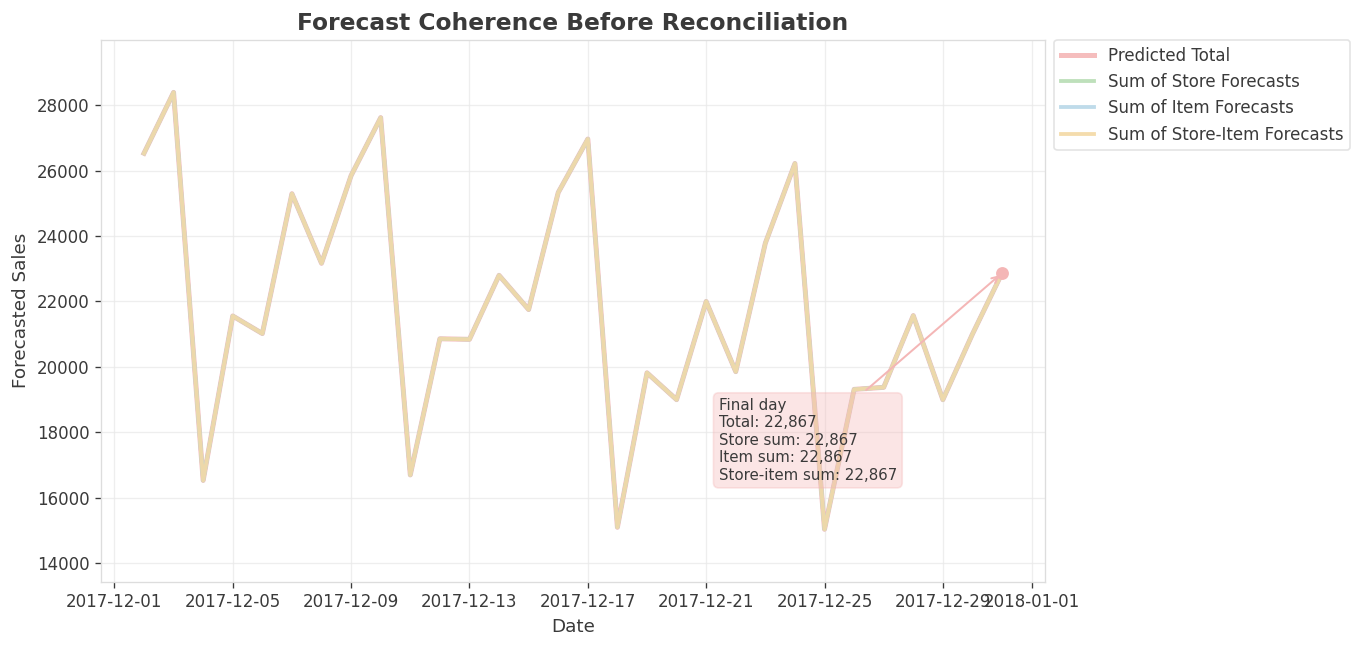

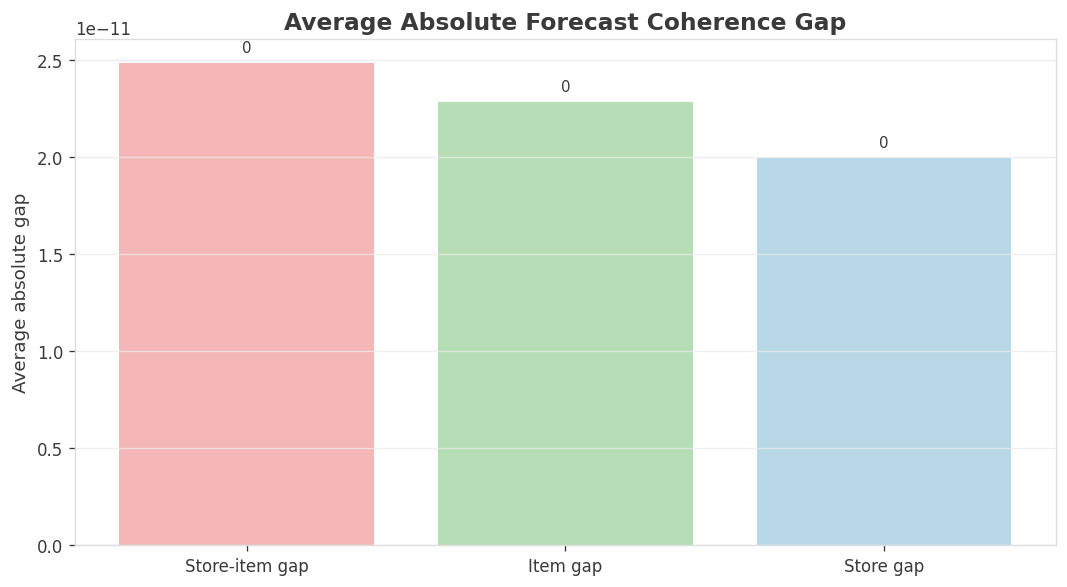

In [10]:
plot_forecast_coherence(
    predicted=lr_pred,
    stores=groups["stores"],
    items=groups["items"],
    store_items=groups["store_items"],
    title="Forecast Coherence Before Reconciliation",
    save_path=PROJECT_ROOT / "outputs" / "figures" / "coherence_before_reconciliation.png"
)
plot_coherence_gap_summary(
    lr_gap_before,
    save_path=PROJECT_ROOT / "outputs" / "figures" / "coherence_gap_before_reconciliation.png"
)

### Coherence Gap Interpretation

The average absolute coherence gaps are extremely small, around `1e-11`.

This means the Linear Regression forecast is already coherent in practical terms. The small non-zero values are caused by floating-point precision rather than actual forecast inconsistency.

Therefore, in this project, reconciliation should not be interpreted as fixing a major coherence failure. Instead, it should be evaluated mainly by whether it improves forecast accuracy at different hierarchy levels while maintaining coherence.

## 9. Seasonal Naive Baseline

Before comparing reconciliation methods, we add a simple weekly seasonal naive baseline.

This model assumes that future sales repeat the pattern from the same weekday in the previous week. Since retail sales often have weekly seasonality, this is a meaningful benchmark.

A more complex model should outperform this baseline to justify its additional complexity.

In [11]:
naive_model = train_naive_seasonal(train, seasonality=7)
naive_pred = naive_model.predict(len(test))

naive_result = evaluate_all_levels(
    actual=test,
    predicted=naive_pred,
    hierarchy_groups=groups,
    model_name="Seasonal Naive"
)

naive_result

,model,level,MAPE,sMAPE,MAE,RMSE
0,Seasonal Naive,Total,34.9758,29.1133,7777.9333,8428.9087
1,Seasonal Naive,Store,35.3060,29.3760,782.5133,844.8047
2,Seasonal Naive,Item,36.2757,30.0144,158.6067,171.1847
3,Seasonal Naive,Store-Item,42.7641,32.9116,16.9039,19.4706


## 10. Baseline Model Comparison

We compare the Seasonal Naive model and Linear Regression across all hierarchy levels.

This answers a practical modeling question: does the lag-based regression model provide value beyond a simple weekly repeat rule?

In [12]:
baseline_results = pd.concat(
    [naive_result, lr_result],
    ignore_index=True
)

baseline_results

,model,level,MAPE,sMAPE,MAE,RMSE
0,Seasonal Naive,Total,34.9758,29.1133,7777.9333,8428.9087
1,Seasonal Naive,Store,35.3060,29.3760,782.5133,844.8047
2,Seasonal Naive,Item,36.2757,30.0144,158.6067,171.1847
3,Seasonal Naive,Store-Item,42.7641,32.9116,16.9039,19.4706
4,Linear Regression,Total,6.7956,7.0316,1514.0357,1951.4305
5,Linear Regression,Store,7.1215,7.3558,159.5645,203.9148
6,Linear Regression,Item,8.5970,8.8581,37.7678,48.0195
7,Linear Regression,Store-Item,20.0480,19.9112,7.7838,9.6642


In [13]:
baseline_results.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "baseline_model_comparison.csv",
    index=False
)

### Baseline MAPE Comparison

The chart below compares MAPE across hierarchy levels. Lower values indicate better forecasting accuracy.

This visualization helps identify whether model improvement is consistent across all levels or concentrated only at certain aggregation levels.

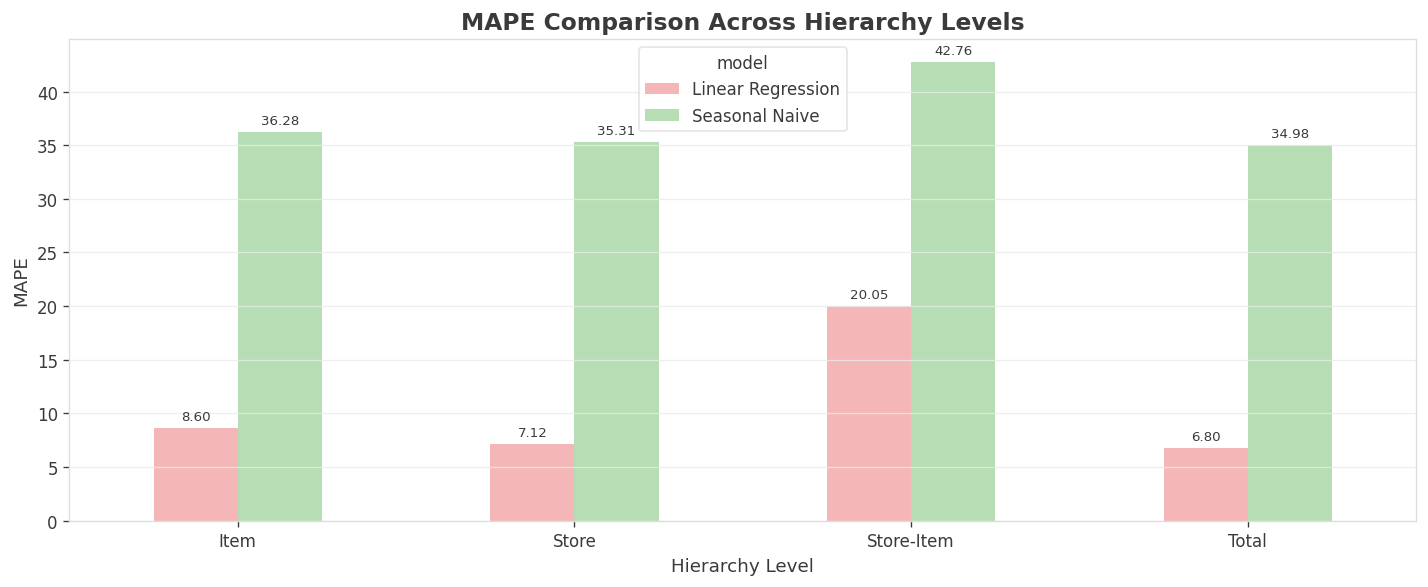

In [14]:
plot_metric_comparison(
    baseline_results,
    metric="MAPE",
    save_path=PROJECT_ROOT / "outputs" / "figures" / "baseline_mape_comparison.png"
)

### Baseline Interpretation

The baseline comparison should be interpreted by hierarchy level rather than only by one overall score.

In hierarchical retail forecasting, a model may perform well at the total level but still struggle at the store-item level. This distinction is important because different business decisions depend on different hierarchy levels.

In [15]:
best_baseline_by_level = (
    baseline_results
    .sort_values(["level", "MAPE"])
    .groupby("level")
    .head(1)
    .reset_index(drop=True)
)

best_baseline_by_level

,model,level,MAPE,sMAPE,MAE,RMSE
0,Linear Regression,Item,8.5970,8.8581,37.7678,48.0195
1,Linear Regression,Store,7.1215,7.3558,159.5645,203.9148
2,Linear Regression,Store-Item,20.0480,19.9112,7.7838,9.6642
3,Linear Regression,Total,6.7956,7.0316,1514.0357,1951.4305


Linear Regression clearly outperforms the Seasonal Naive baseline across all hierarchy levels.

The Seasonal Naive model has much higher MAPE:

- **Total:** 34.98%
- **Store:** 35.31%
- **Item:** 36.28%
- **Store-item:** 42.76%

Compared with this baseline, Linear Regression reduces MAPE substantially at every level. This suggests that a lag-based global regression model captures more information than simply repeating the previous weekly pattern.

The largest practical improvement appears at the aggregate and middle hierarchy levels, while the store-item level remains the most challenging even after using Linear Regression.

## 11. Forecast Reconciliation

Forecast reconciliation is used to make forecasts coherent across hierarchy levels.

We compare three reconciliation strategies:

- **Bottom-Up**: starts from the most granular store-item forecasts and aggregates upward.
- **Top-Down**: starts from the total forecast and distributes it downward.
- **MinT**: adjusts forecasts using an error-based reconciliation strategy.

The goal is not only to improve accuracy, but also to make the forecast structure usable for business planning.

In [16]:
bottom_up_pred = apply_bottom_up(lr_pred, hierarchy)
top_down_pred = apply_top_down(train, lr_pred, hierarchy)
mint_pred = apply_mint(train, lr_pred, hierarchy)

## 12. Evaluate Reconciled Forecasts

We now evaluate the reconciled forecasts using the same metrics and hierarchy levels.

The underlying model remains Linear Regression. The only difference is the reconciliation method applied after prediction. This makes the comparison fair and focused.

In [17]:
bottom_up_result = evaluate_all_levels(
    actual=test,
    predicted=bottom_up_pred,
    hierarchy_groups=groups,
    model_name="LR + Bottom-Up"
)

top_down_result = evaluate_all_levels(
    actual=test,
    predicted=top_down_pred,
    hierarchy_groups=groups,
    model_name="LR + Top-Down"
)

mint_result = evaluate_all_levels(
    actual=test,
    predicted=mint_pred,
    hierarchy_groups=groups,
    model_name="LR + MinT"
)

reconciliation_results = pd.concat(
    [
        lr_result,
        bottom_up_result,
        top_down_result,
        mint_result
    ],
    ignore_index=True
)

reconciliation_results

,model,level,MAPE,sMAPE,MAE,RMSE
0,Linear Regression,Total,6.7956,7.0316,1514.0357,1951.4305
1,Linear Regression,Store,7.1215,7.3558,159.5645,203.9148
2,Linear Regression,Item,8.5970,8.8581,37.7678,48.0195
3,Linear Regression,Store-Item,20.0480,19.9112,7.7838,9.6642
4,LR + Bottom-Up,Total,6.7956,7.0316,1514.0357,1951.4305
5,LR + Bottom-Up,Store,7.1215,7.3558,159.5645,203.9148
6,LR + Bottom-Up,Item,8.5970,8.8581,37.7678,48.0195
7,LR + Bottom-Up,Store-Item,20.0480,19.9112,7.7838,9.6642
8,LR + Top-Down,Total,6.7956,7.0316,1514.0357,1951.4305
9,LR + Top-Down,Store,6.9755,7.2068,155.6783,199.2314


In [18]:
reconciliation_results.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "reconciliation_results.csv",
    index=False
)

The reconciliation results show that **Top-Down reconciliation provides the strongest improvement** among the tested methods.

Compared with the original Linear Regression forecast:

- Store MAPE improves from **7.12%** to **6.98%**
- Item MAPE improves from **8.60%** to **7.74%**
- Store-item MAPE improves from **20.05%** to **15.50%**
- Total MAPE remains unchanged at **6.80%**

Bottom-Up and MinT produce almost identical results to the original Linear Regression forecast in this setup. The main useful reconciliation method here is therefore Top-Down, because it improves lower-level accuracy while preserving total-level performance.

### Reconciliation MAPE Comparison

This chart compares the original Linear Regression forecast with three reconciled versions.

A useful reconciliation method should ideally improve hierarchy consistency without strongly damaging predictive accuracy.

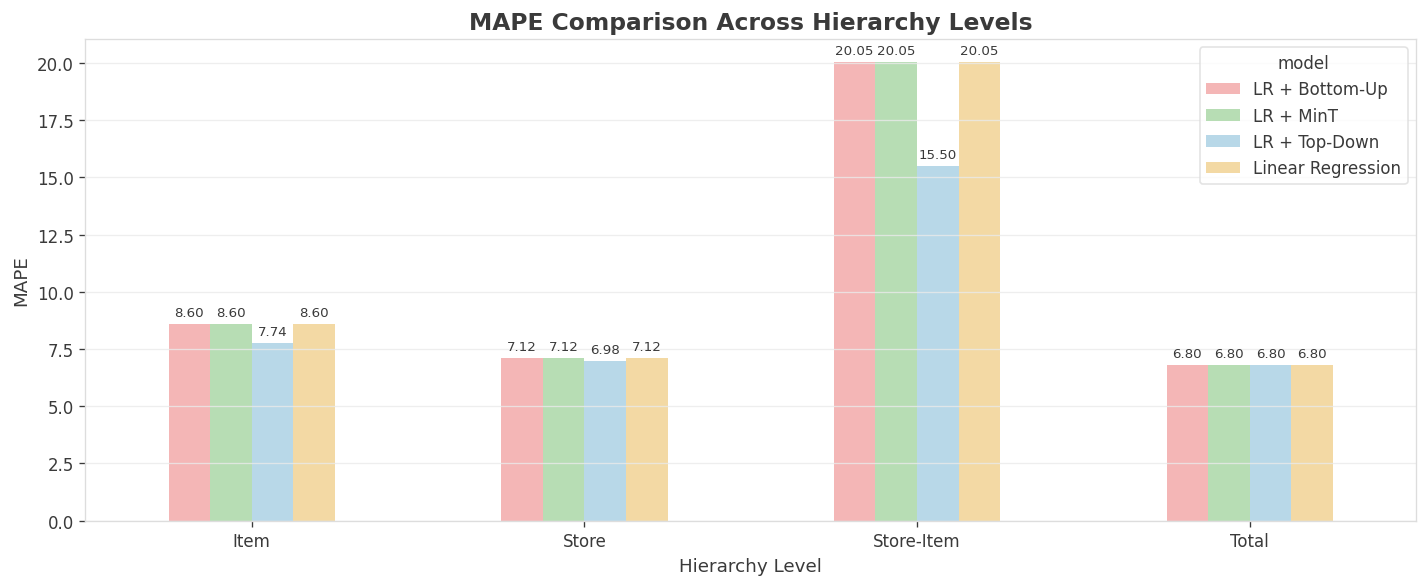

In [19]:
plot_metric_comparison(
    reconciliation_results,
    metric="MAPE",
    save_path=PROJECT_ROOT / "outputs" / "figures" / "reconciliation_mape_comparison.png"
)

## 13. Coherence After Reconciliation

After Top-Down reconciliation, the forecast remains coherent across all hierarchy levels.

The average absolute gaps become even smaller, but both the before and after gaps are already close to zero. Therefore, the key value of Top-Down reconciliation in this project is not simply coherence correction.

The more important finding is that Top-Down reconciliation improves accuracy at the store, item, and store-item levels while keeping the total-level forecast unchanged.

In [20]:
top_down_gap_after = calculate_coherence_gap(
    predicted=top_down_pred,
    stores=groups["stores"],
    items=groups["items"],
    store_items=groups["store_items"]
)

top_down_gap_after.head()

,Total,Sum_Store,Sum_Item,Sum_Store_Item,Store_Gap,Item_Gap,Store_Item_Gap,Abs_Store_Gap,Abs_Item_Gap,Abs_Store_Item_Gap
date,,,,,,,,,,
2017-12-02,26527.920994,26527.920994,26527.920994,26527.920994,3.637979e-12,3.637979e-12,2.546585e-11,3.637979e-12,3.637979e-12,2.546585e-11
2017-12-03,28388.275670,28388.275670,28388.275670,28388.275670,7.275958e-12,0.000000e+00,0.000000e+00,7.275958e-12,0.000000e+00,0.000000e+00
2017-12-04,16529.997682,16529.997682,16529.997682,16529.997682,3.637979e-12,3.637979e-12,2.546585e-11,3.637979e-12,3.637979e-12,2.546585e-11
2017-12-05,21555.725041,21555.725041,21555.725041,21555.725041,7.275958e-12,1.455192e-11,1.091394e-11,7.275958e-12,1.455192e-11,1.091394e-11
2017-12-06,21018.399695,21018.399695,21018.399695,21018.399695,3.637979e-12,7.275958e-12,-7.275958e-12,3.637979e-12,7.275958e-12,7.275958e-12


In [21]:
coherence_gap_summary_after = pd.DataFrame({
    "gap_type": ["Store gap", "Item gap", "Store-item gap"],
    "average_absolute_gap": [
        top_down_gap_after["Abs_Store_Gap"].mean(),
        top_down_gap_after["Abs_Item_Gap"].mean(),
        top_down_gap_after["Abs_Store_Item_Gap"].mean()
    ],
    "max_absolute_gap": [
        top_down_gap_after["Abs_Store_Gap"].max(),
        top_down_gap_after["Abs_Item_Gap"].max(),
        top_down_gap_after["Abs_Store_Item_Gap"].max()
    ]
})

coherence_gap_summary_after

,gap_type,average_absolute_gap,max_absolute_gap
0,Store gap,5.578234e-12,1.091394e-11
1,Item gap,6.002665e-12,1.455192e-11
2,Store-item gap,1.297546e-11,4.365575e-11


In [22]:
coherence_gap_summary_after.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "coherence_gap_after_top_down.csv",
    index=False
)

In [23]:
gap_comparison = coherence_gap_summary_before.merge(
    coherence_gap_summary_after,
    on="gap_type",
    suffixes=("_before", "_after")
)

gap_comparison["average_gap_reduction"] = (
    gap_comparison["average_absolute_gap_before"]
    - gap_comparison["average_absolute_gap_after"]
)

gap_comparison["average_gap_reduction_pct"] = (
    gap_comparison["average_gap_reduction"]
    / gap_comparison["average_absolute_gap_before"]
    * 100
)

gap_comparison

,gap_type,average_absolute_gap_before,max_absolute_gap_before,average_absolute_gap_after,max_absolute_gap_after,average_gap_reduction,average_gap_reduction_pct
0,Store gap,1.994825e-11,4.729372e-11,5.578234e-12,1.091394e-11,1.437002e-11,72.036474
1,Item gap,2.285863e-11,5.093170e-11,6.002665e-12,1.455192e-11,1.685597e-11,73.740053
2,Store-item gap,2.485952e-11,6.548362e-11,1.297546e-11,4.365575e-11,1.188406e-11,47.804878


### Coherence Gap Reduction Interpretation

The gap reduction percentages look large, with reductions of around **72.0%** for the store gap, **73.7%** for the item gap, and **47.8%** for the store-item gap.

However, these percentages should be interpreted carefully. The absolute gaps before reconciliation are already around `1e-11`, which is effectively zero. Therefore, the percentage reduction is mathematically visible but not practically meaningful from a business perspective.

The stronger business takeaway is that Top-Down reconciliation improves lower-level forecast accuracy, especially at the store-item level.

In [24]:
gap_comparison.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "coherence_gap_reduction.csv",
    index=False
)

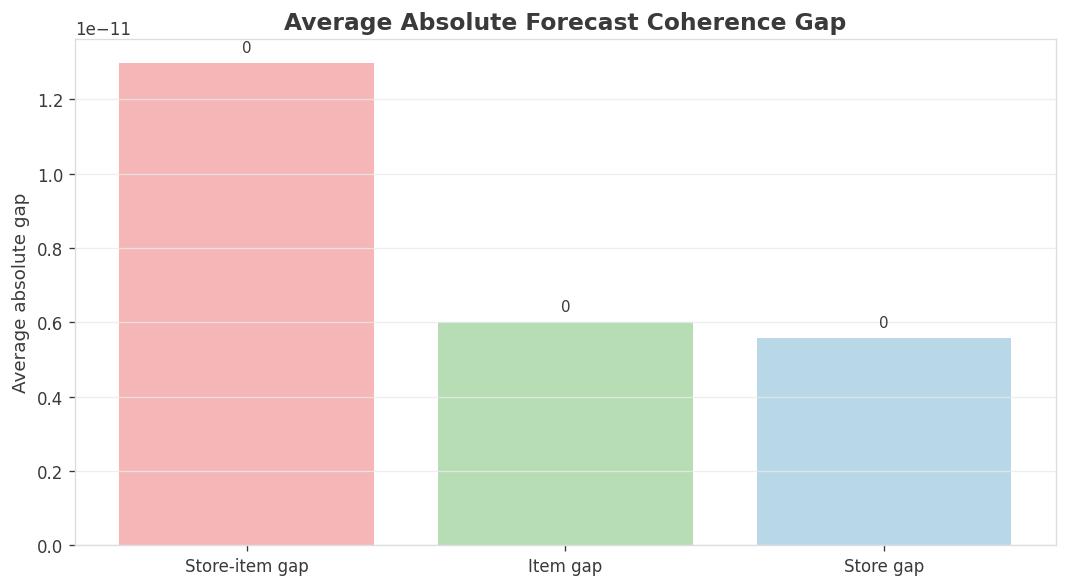

In [25]:
plot_coherence_gap_summary(
    top_down_gap_after,
    save_path=PROJECT_ROOT / "outputs" / "figures" / "coherence_gap_after_top_down.png"
)

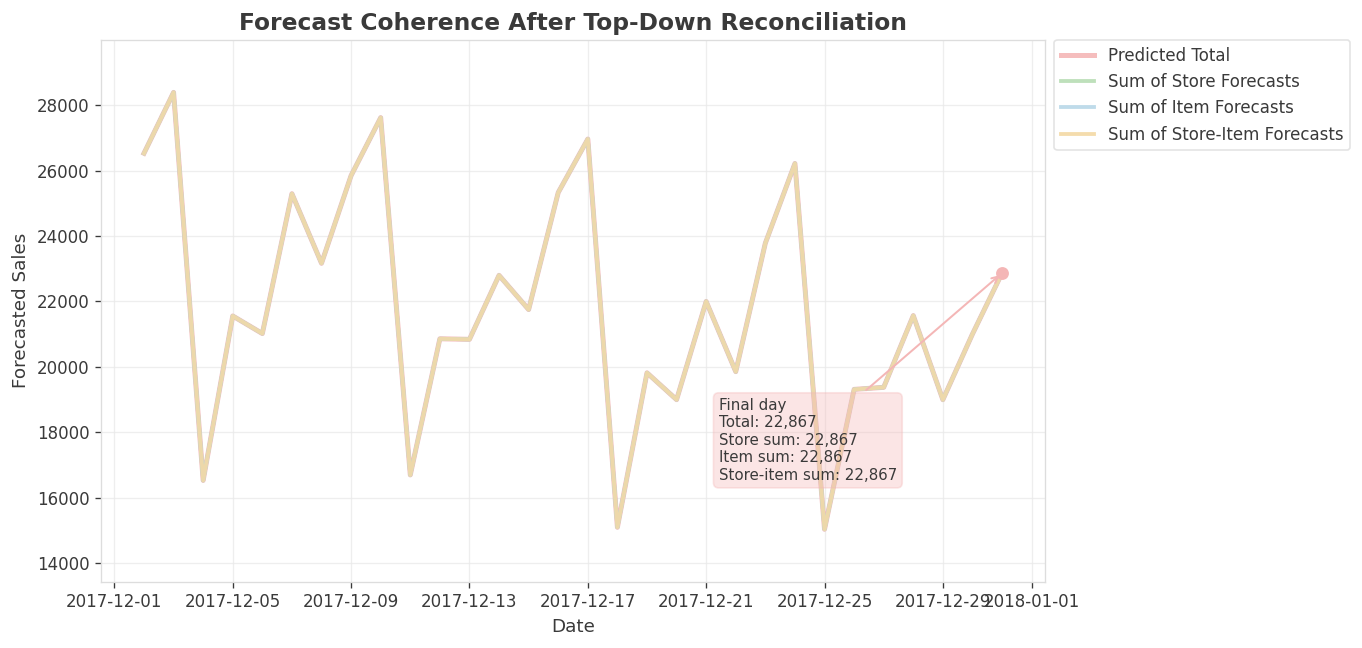

In [26]:
plot_forecast_coherence(
    predicted=top_down_pred,
    stores=groups["stores"],
    items=groups["items"],
    store_items=groups["store_items"],
    title="Forecast Coherence After Top-Down Reconciliation",
    save_path=PROJECT_ROOT / "outputs" / "figures" / "coherence_after_top_down.png"
)

## 14. Best Method by Hierarchy Level

Instead of selecting one model only by the total-level score, we identify the best-performing method at each hierarchy level.

This is more useful for business interpretation because different teams rely on different levels of the hierarchy.

In [27]:
best_by_level = (
    reconciliation_results
    .sort_values(["level", "MAPE"])
    .groupby("level")
    .head(1)
    .reset_index(drop=True)
)

best_by_level

,model,level,MAPE,sMAPE,MAE,RMSE
0,LR + Top-Down,Item,7.7429,7.9728,34.6052,44.2082
1,LR + Top-Down,Store,6.9755,7.2068,155.6783,199.2314
2,LR + Top-Down,Store-Item,15.5008,15.2161,6.1184,7.6319
3,Linear Regression,Total,6.7956,7.0316,1514.0357,1951.4305


In [28]:
best_by_level.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "best_method_by_level.csv",
    index=False
)

## 15. Store-Item Level Error Analysis

The store-item level has the highest forecasting error, so we examine which specific store-item combinations are hardest to predict.

This is important from a business perspective because high-error combinations may create inventory risks, such as stockouts or overstock.

In [29]:
def component_mape_table(actual, predicted, components):
    rows = []

    for component in components:
        actual_series = actual[component].to_dataframe().iloc[:, 0]
        pred_series = predicted[component].to_dataframe().iloc[:, 0]

        aligned = pd.concat(
            [actual_series.rename("actual"), pred_series.rename("predicted")],
            axis=1,
            join="inner"
        ).dropna()

        mape_value = (
            (aligned["actual"] - aligned["predicted"]).abs()
            / aligned["actual"].replace(0, np.nan).abs()
        ).mean() * 100

        mae_value = (aligned["actual"] - aligned["predicted"]).abs().mean()

        rows.append({
            "component": component,
            "MAPE": mape_value,
            "MAE": mae_value,
            "actual_mean_sales": aligned["actual"].mean(),
            "predicted_mean_sales": aligned["predicted"].mean()
        })

    return pd.DataFrame(rows).sort_values("MAPE", ascending=False)


store_item_errors = component_mape_table(
    actual=test,
    predicted=lr_pred,
    components=groups["store_items"]
)

store_item_errors.head(10)

,component,MAPE,MAE,actual_mean_sales,predicted_mean_sales
340,store_7_item_41,47.634192,4.742576,12.000000,12.775776
304,store_7_item_5,44.638174,4.338250,11.033333,10.270454
346,store_7_item_47,41.172934,4.359237,12.700000,12.629282
226,store_5_item_27,41.011741,3.941472,14.366667,14.927151
303,store_7_item_4,40.478633,4.313838,12.233333,12.055743
326,store_7_item_27,39.175402,4.089805,11.700000,12.041399
240,store_5_item_41,38.855822,4.255008,13.766667,13.233155
200,store_5_item_1,38.347958,4.918482,15.066667,14.673911
215,store_5_item_16,38.211770,4.636335,16.300000,16.867025
236,store_5_item_37,37.880500,6.107096,17.333333,18.852887


In [30]:
store_item_errors.to_csv(
    PROJECT_ROOT / "outputs" / "tables" / "store_item_error_analysis.csv",
    index=False
)

### Top 10 Hardest Store-Item Series to Forecast

The chart below highlights the store-item combinations with the highest MAPE.

These combinations deserve further business investigation because they may represent unstable demand, low sales volume, promotion effects, or local market-specific behavior.

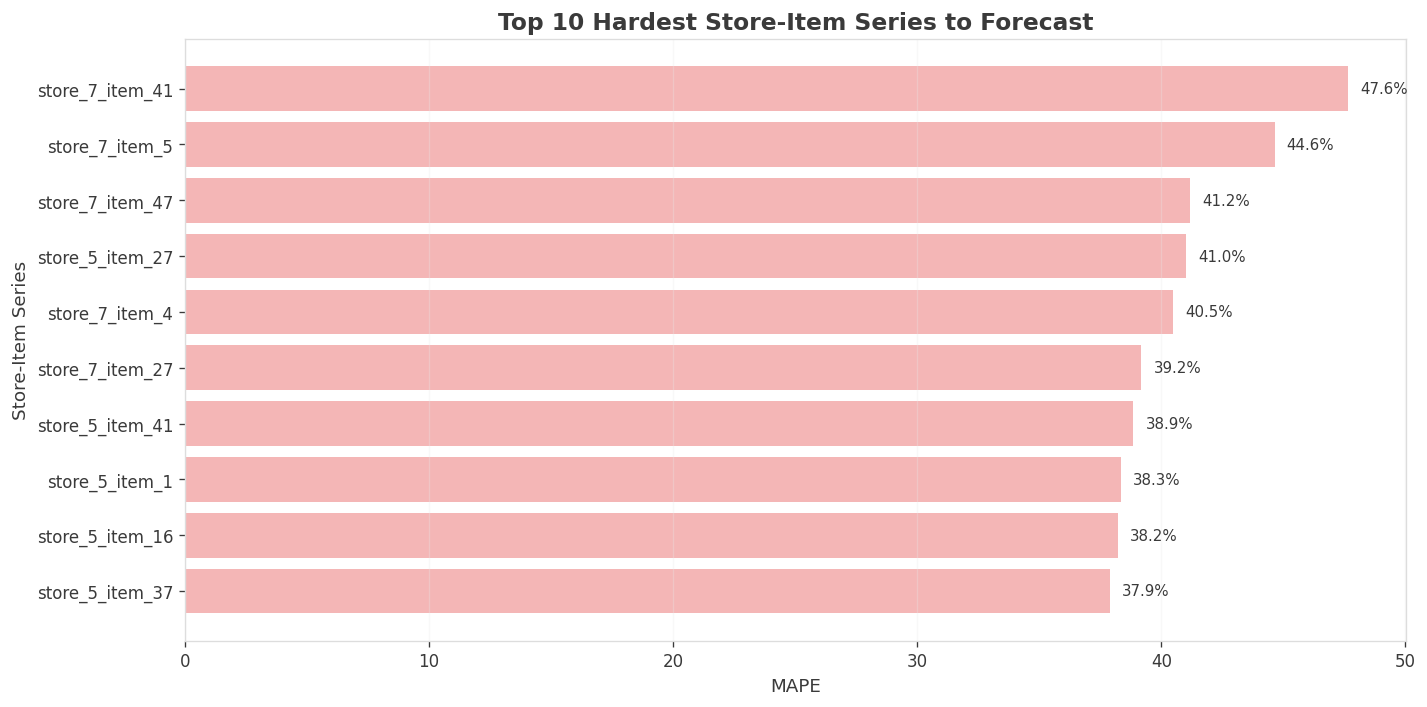

In [31]:
top_10_errors = store_item_errors.head(10).copy()

plt.figure(figsize=(12, 6))
bars = plt.barh(
    top_10_errors["component"],
    top_10_errors["MAPE"],
    color="#F4B6B6"
)

plt.gca().invert_yaxis()
plt.title("Top 10 Hardest Store-Item Series to Forecast")
plt.xlabel("MAPE")
plt.ylabel("Store-Item Series")
plt.grid(axis="x", alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    PROJECT_ROOT / "outputs" / "figures" / "top_10_store_item_errors.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

The most difficult store-item combinations have MAPE values between approximately **37.9%** and **47.6%**.

Several high-error series come from **store 7** and **store 5**, such as `store_7_item_41`, `store_7_item_5`, and `store_7_item_47`. This suggests that forecasting difficulty is not evenly distributed across all store-item pairs.

From a business perspective, these high-error combinations should be investigated further. Possible explanations include low sales volume, irregular local demand, promotion effects, product-specific seasonality, or store-specific customer behavior.

## 16. Forecast vs Actual: Total Sales

Finally, we compare actual total sales with the predicted total sales.

This gives a direct visual check of whether the model captures the short-term demand movement during the test period.

In [32]:
actual_total = test["Total"].to_dataframe().iloc[:, 0]
pred_total = lr_pred["Total"].to_dataframe().iloc[:, 0]

forecast_compare_total = pd.concat(
    [
        actual_total.rename("actual_total_sales"),
        pred_total.rename("predicted_total_sales")
    ],
    axis=1,
    join="inner"
)

forecast_compare_total["absolute_error"] = (
    forecast_compare_total["actual_total_sales"]
    - forecast_compare_total["predicted_total_sales"]
).abs()

forecast_compare_total.head()

,actual_total_sales,predicted_total_sales,absolute_error
date,,,
2017-12-02,24538.0,26527.920994,1989.920994
2017-12-03,26533.0,28388.275670,1855.275670
2017-12-04,17382.0,16529.997682,852.002318
2017-12-05,20177.0,21555.725041,1378.725041
2017-12-06,20340.0,21018.399695,678.399695


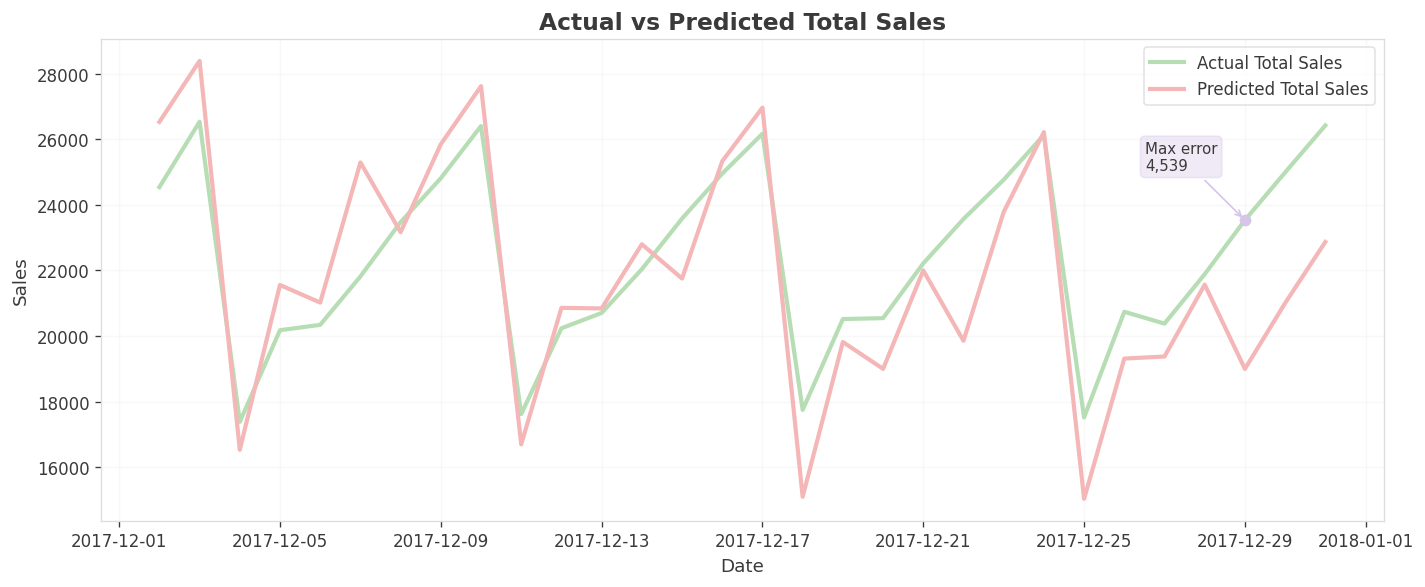

In [33]:
plt.figure(figsize=(12, 5))

plt.plot(
    forecast_compare_total.index,
    forecast_compare_total["actual_total_sales"],
    label="Actual Total Sales",
    color="#B7DDB4",
    linewidth=2.5
)

plt.plot(
    forecast_compare_total.index,
    forecast_compare_total["predicted_total_sales"],
    label="Predicted Total Sales",
    color="#F4B6B6",
    linewidth=2.5
)

max_error_date = forecast_compare_total["absolute_error"].idxmax()
max_error_value = forecast_compare_total.loc[max_error_date, "absolute_error"]

plt.scatter(
    max_error_date,
    forecast_compare_total.loc[max_error_date, "actual_total_sales"],
    color="#D6C4E9",
    zorder=5
)

plt.annotate(
    f"Max error\n{max_error_value:,.0f}",
    xy=(max_error_date, forecast_compare_total.loc[max_error_date, "actual_total_sales"]),
    xytext=(-60, 30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="#D6C4E9"),
    bbox=dict(boxstyle="round,pad=0.3", fc="#D6C4E9", ec="#D6C4E9", alpha=0.35),
    fontsize=9
)

plt.title("Actual vs Predicted Total Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "outputs" / "figures" / "actual_vs_predicted_total_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The total-level forecast captures the short-term movement reasonably well, including the weekly peaks and drops in December 2017.

The largest absolute error is approximately **4,539** sales units. This indicates that even though the total-level MAPE is relatively low at **6.80%**, there are still individual days where the model underestimates or overestimates demand.

From a planning perspective, these large-error days are important because they may create inventory pressure even when the average forecast performance looks acceptable.

## 17. Final Project Summary

This project built a hierarchical retail demand forecasting workflow across four business levels:

- total sales;
- store-level sales;
- item-level sales;
- store-item-level sales.

The dataset contains **1,826 daily observations** and **561 hierarchical time series components**, including 1 total series, 10 store series, 50 item series, and 500 store-item series.

The main modeling result is that the Linear Regression model clearly outperforms the Seasonal Naive baseline across all hierarchy levels. Linear Regression achieves a **Total MAPE of 6.80%**, **Store MAPE of 7.12%**, **Item MAPE of 8.60%**, and **Store-item MAPE of 20.05%**. This confirms that a lag-based global model captures more useful demand patterns than a simple weekly repeat rule.

A key insight is that forecasting difficulty increases at lower hierarchy levels. Aggregate-level forecasts are more stable, while store-item-level forecasts are much harder because they contain more local variation and demand noise.

The reconciliation experiment shows that the original Linear Regression forecast is already coherent in practical terms, with coherence gaps close to zero. Therefore, reconciliation is not mainly needed to fix inconsistency in this case. Instead, the most valuable result is that **Top-Down reconciliation improves lower-level accuracy** while keeping the total forecast unchanged. In particular, Store-item MAPE improves from **20.05%** to **15.50%**, which is the most important improvement for replenishment-related decisions.

The store-item error analysis further shows that forecasting risk is concentrated in specific product-store combinations, especially several series from store 7 and store 5. These high-error combinations should be prioritized for further business investigation.

From a business perspective, this workflow can support:

- total-level demand planning;
- store-level staffing and logistics planning;
- item-level category management;
- store-item-level inventory replenishment;
- identification of high-risk store-item combinations with unstable demand.

Future improvements could include promotion features, holiday indicators, price information, rolling-window backtesting, and more advanced global forecasting models.